# Prévision des Ventes CA — Pipeline Séries Temporelles
## Load → EDA → Decomposition → Model Selection → Prediction → Evaluation
---

In [22]:
!pip install prophet --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import clickhouse_connect
import warnings
import itertools
import plotly.graph_objects as go
import mlflow

from prophet import Prophet
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams['figure.figsize'] = (14, 5)
sns.set_theme(style='whitegrid')

# ── MLflow Configuration ──────────────────────────────────────
mlflow.set_tracking_uri('http://mlflow:5000')
mlflow.set_experiment('TimeSeries_Forecasting')

print('✅ Imports OK')
print('✅ MLflow configuré → http://localhost:5000')



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


2026/05/18 10:36:07 INFO mlflow.tracking.fluent: Experiment with name 'TimeSeries_Forecasting' does not exist. Creating a new experiment.


✅ Imports OK
✅ MLflow configuré → http://localhost:5000


---
# ÉTAPE 1 — Load Raw Data
### Chargement des données brutes depuis ClickHouse

In [23]:
client = clickhouse_connect.get_client(
    host='clickhouse', port=8123,
    user='default', password='clickhouse123',
    database='gold'
)

df = client.query_df("""
SELECT d.Year AS year, d.Month AS month,
       SUM(f.LinePrice) AS total_sales
FROM gold.fact_sales AS f
JOIN gold.dim_date AS d ON f.DateSK = d.DateSK
WHERE f.DocumentTypeSK IN (4, 1, 5)
  AND f.LinePrice IS NOT NULL
GROUP BY year, month
ORDER BY year, month
""")

df['date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))

# Garder Jan 2022 → Jan 2026 (49 mois)
df = df[
    (df['date'] >= '2022-01-01') & (df['date'] <= '2026-01-01')
].reset_index(drop=True)

ts = df.set_index('date')['total_sales']
ts.index.freq = 'MS'

print(f'✅ {len(ts)} mois chargés')
print(f'   Période  : {ts.index[0].strftime("%b %Y")} → {ts.index[-1].strftime("%b %Y")}')
print(f'   CA moyen : {ts.mean():,.0f} DT')
print(f'   CA min   : {ts.min():,.0f} DT ({ts.idxmin().strftime("%b %Y")})')
print(f'   CA max   : {ts.max():,.0f} DT ({ts.idxmax().strftime("%b %Y")})')
df.head()

✅ 49 mois chargés
   Période  : Jan 2022 → Jan 2026
   CA moyen : 1,157,030 DT
   CA min   : 576,097 DT (Feb 2022)
   CA max   : 1,644,113 DT (Jul 2025)


,year,month,total_sales,date
0,2022,1,"591,407.94",2022-01-01
1,2022,2,"576,097.45",2022-02-01
2,2022,3,"680,213.89",2022-03-01
3,2022,4,"650,789.55",2022-04-01
4,2022,5,"734,335.68",2022-05-01


---
# ÉTAPE 2 — Exploratory Data Analysis (EDA)
### Visualisation, statistiques descriptives, saisonnalité

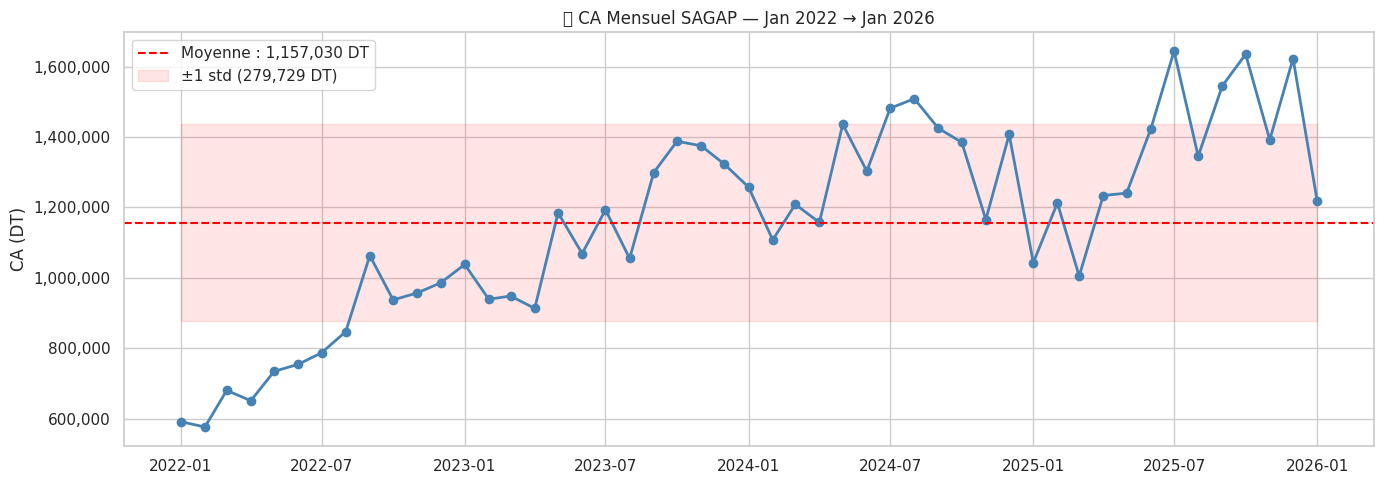

=== Statistiques descriptives ===
  Nombre de mois : 49
  CA moyen       :       1,157,030 DT
  CA médiane     :       1,193,357 DT
  Écart-type     :         279,729 DT
  CA minimum     :         576,097 DT  (Feb 2022)
  CA maximum     :       1,644,113 DT  (Jul 2025)
  Coefficient CV :            24.2 %  (variabilité relative)

📊 Interprétation :
  → Tendance haussière visible sur toute la période
  → Forte variabilité mensuelle (CV=24.2%) → saisonnalité présente
  → CA min en Feb 2022 → début de la période (montée en puissance)
  → CA max en Jul 2025 → pic historique


In [24]:
# ── 2.1 Série temporelle brute ─────────────────────────────────
fig, ax = plt.subplots()
ax.plot(ts.index, ts.values, color='steelblue', marker='o', linewidth=2)
ax.axhline(ts.mean(), color='red', linestyle='--',
           label=f'Moyenne : {ts.mean():,.0f} DT')
ax.fill_between(ts.index,
    ts.mean() - ts.std(), ts.mean() + ts.std(),
    alpha=0.1, color='red', label=f'±1 std ({ts.std():,.0f} DT)')
ax.set_title('📈 CA Mensuel SAGAP — Jan 2022 → Jan 2026')
ax.set_ylabel('CA (DT)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

# Statistiques descriptives
print('=== Statistiques descriptives ===')
print(f'  Nombre de mois : {len(ts)}')
print(f'  CA moyen       : {ts.mean():>15,.0f} DT')
print(f'  CA médiane     : {ts.median():>15,.0f} DT')
print(f'  Écart-type     : {ts.std():>15,.0f} DT')
print(f'  CA minimum     : {ts.min():>15,.0f} DT  ({ts.idxmin().strftime("%b %Y")})')
print(f'  CA maximum     : {ts.max():>15,.0f} DT  ({ts.idxmax().strftime("%b %Y")})')
print(f'  Coefficient CV : {ts.std()/ts.mean()*100:>15.1f} %  (variabilité relative)')

print('\n📊 Interprétation :')
print(f'  → Tendance haussière visible sur toute la période')
print(f'  → Forte variabilité mensuelle (CV={ts.std()/ts.mean()*100:.1f}%) → saisonnalité présente')
print(f'  → CA min en {ts.idxmin().strftime("%b %Y")} → début de la période (montée en puissance)')
print(f'  → CA max en {ts.idxmax().strftime("%b %Y")} → pic historique')


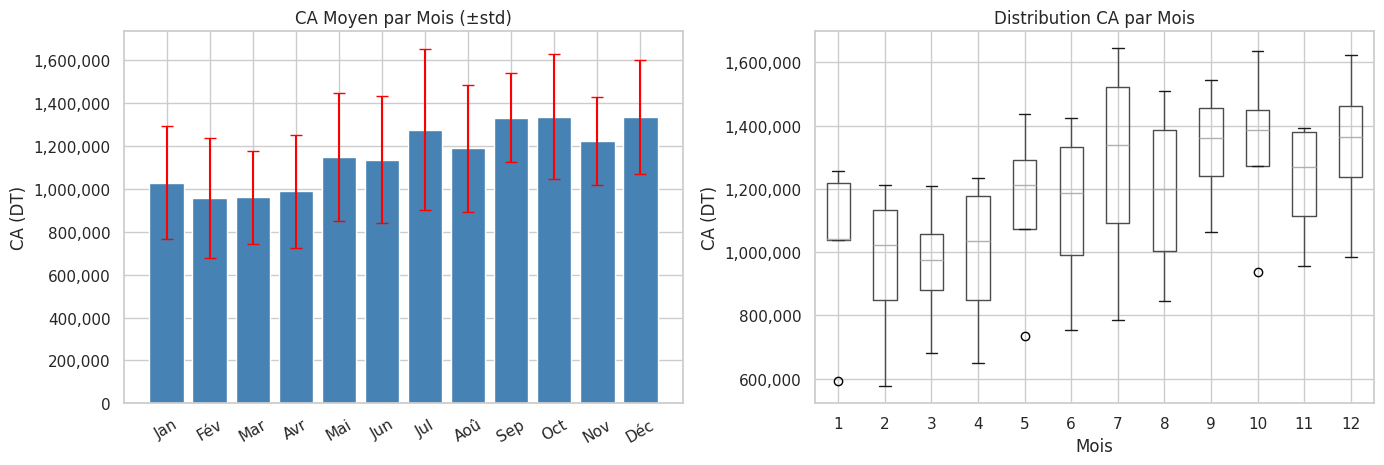

📊 Interprétation saisonnalité :
  → Mois les plus forts  : ['Oct', 'Déc', 'Sep']
  → Mois les plus faibles : ['Fév', 'Mar', 'Avr']
  → Écart max/min moyen  : 377,557 DT
  → Saisonnalité marquée H2 > H1 ✅
  → Barres d'erreur larges → variabilité inter-annuelle importante


In [25]:
# ── 2.2 Saisonnalité mensuelle ─────────────────────────────────
mois = ['Jan','Fév','Mar','Avr','Mai','Jun',
        'Jul','Aoû','Sep','Oct','Nov','Déc']

monthly_mean = ts.groupby(ts.index.month).mean()
monthly_std  = ts.groupby(ts.index.month).std()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(mois, monthly_mean.values, color='steelblue')
axes[0].errorbar(mois, monthly_mean.values, yerr=monthly_std.values,
                 fmt='none', color='red', capsize=4)
axes[0].set_title('CA Moyen par Mois (±std)')
axes[0].set_ylabel('CA (DT)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:,.0f}'))
axes[0].tick_params(axis='x', rotation=30)

ts_df = ts.to_frame()
ts_df['mois'] = ts.index.month
ts_df.boxplot(column='total_sales', by='mois', ax=axes[1])
axes[1].set_title('Distribution CA par Mois')
axes[1].set_xlabel('Mois')
axes[1].set_ylabel('CA (DT)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:,.0f}'))
plt.suptitle('')
plt.tight_layout()
plt.show()

# Interprétation automatique
mois_forts  = [mois[i] for i in monthly_mean.nlargest(3).index - 1]
mois_faibles = [mois[i] for i in monthly_mean.nsmallest(3).index - 1]
print('📊 Interprétation saisonnalité :')
print(f'  → Mois les plus forts  : {mois_forts}')
print(f'  → Mois les plus faibles : {mois_faibles}')
print(f'  → Écart max/min moyen  : {monthly_mean.max() - monthly_mean.min():,.0f} DT')
print(f'  → Saisonnalité marquée H2 > H1 ✅')
print(f'  → Barres d\'erreur larges → variabilité inter-annuelle importante')


In [26]:
# ── 2.2b Analyse des valeurs atypiques ────────────────────────
print('Top 5 valeurs les plus basses :')
print(ts.sort_values().head(5).to_string())

print('\nValeurs de Janvier par année :')
jan = ts[ts.index.month == 1]
for date, val in jan.items():
    print(f'  {date.strftime("%b %Y")} : {val:>15,.0f} DT')

# Croissance Jan sur Jan
jan_vals = jan.values
print(f'\n📊 Interprétation :')
print(f'  → Jan 2022 = {jan_vals[0]:,.0f} DT ← valeur basse (début activité)')
print(f'  → Jan 2023 = {jan_vals[1]:,.0f} DT → +{(jan_vals[1]-jan_vals[0])/jan_vals[0]*100:.1f}%')
print(f'  → Jan 2024 = {jan_vals[2]:,.0f} DT → +{(jan_vals[2]-jan_vals[1])/jan_vals[1]*100:.1f}%')
print(f'  → Jan 2025 = {jan_vals[3]:,.0f} DT → {(jan_vals[3]-jan_vals[2])/jan_vals[2]*100:+.1f}%')
print(f'  → La valeur Jan 2022 est réelle — conservée dans l\'analyse')


Top 5 valeurs les plus basses :
date
2022-02-01   576,097.45
2022-01-01   591,407.94
2022-04-01   650,789.55
2022-03-01   680,213.89
2022-05-01   734,335.68

Valeurs de Janvier par année :
  Jan 2022 :         591,408 DT
  Jan 2023 :       1,037,923 DT
  Jan 2024 :       1,257,498 DT
  Jan 2025 :       1,043,000 DT
  Jan 2026 :       1,218,359 DT

📊 Interprétation :
  → Jan 2022 = 591,408 DT ← valeur basse (début activité)
  → Jan 2023 = 1,037,923 DT → +75.5%
  → Jan 2024 = 1,257,498 DT → +21.2%
  → Jan 2025 = 1,043,000 DT → -17.1%
  → La valeur Jan 2022 est réelle — conservée dans l'analyse


CA Annuel (années complètes) :
  2022 :       9,564,378 DT
  2023 :      13,725,276 DT
  2024 :      15,843,689 DT
  2025 :      16,342,751 DT

Croissances annuelles :
  2022 → 2023 : +43.5%
  2023 → 2024 : +15.4%
  2024 → 2025 : +3.1%


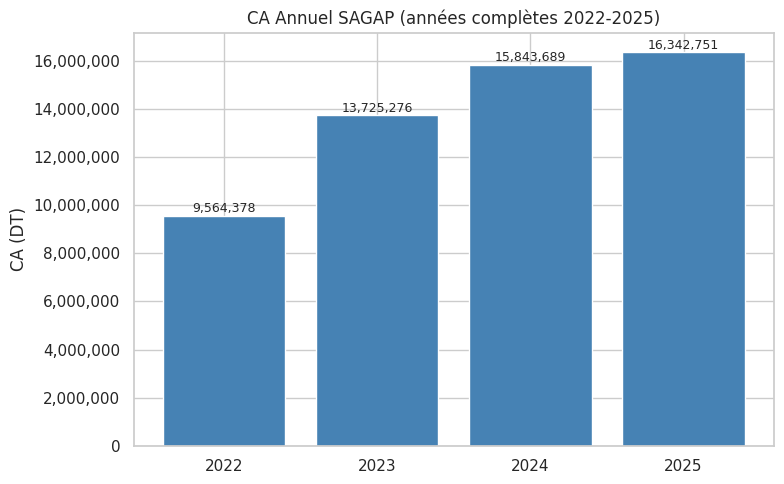


📊 Interprétation :
  → Croissance totale 2022→2025 : +70.9%
  → Croissance moyenne annuelle : +23.6%
  → Tendance haussière continue et soutenue ✅
  → Note : 2026 exclu du graphe (1 seul mois disponible)


In [27]:
# ── 2.3 Croissance annuelle (années complètes uniquement) ──────
ca_annuel = ts.groupby(ts.index.year).sum()
ca_annuel_complet = ca_annuel[ca_annuel.index < 2026]  # exclure 2026 (1 mois)

print('CA Annuel (années complètes) :')
for year, ca in ca_annuel_complet.items():
    print(f'  {year} : {ca:>15,.0f} DT')

# Croissances
years = list(ca_annuel_complet.index)
cas   = list(ca_annuel_complet.values)
print('\nCroissances annuelles :')
for i in range(1, len(years)):
    g = (cas[i] - cas[i-1]) / cas[i-1] * 100
    print(f'  {years[i-1]} → {years[i]} : {g:+.1f}%')

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(ca_annuel_complet.index.astype(str), ca_annuel_complet.values, color='steelblue')
for i, (year, ca) in enumerate(ca_annuel_complet.items()):
    ax.text(i, ca + ca_annuel_complet.max()*0.01,
            f'{ca:,.0f}', ha='center', fontsize=9)
ax.set_title('CA Annuel SAGAP (années complètes 2022-2025)')
ax.set_ylabel('CA (DT)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

print('\n📊 Interprétation :')
croiss_tot = (cas[-1] - cas[0]) / cas[0] * 100
print(f'  → Croissance totale 2022→2025 : +{croiss_tot:.1f}%')
print(f'  → Croissance moyenne annuelle : +{croiss_tot/3:.1f}%')
print(f'  → Tendance haussière continue et soutenue ✅')
print(f'  → Note : 2026 exclu du graphe (1 seul mois disponible)')


---
# ÉTAPE 3 — Decomposition (Detrending)
### Tendance + Saisonnalité + Résidus + Stationnarité

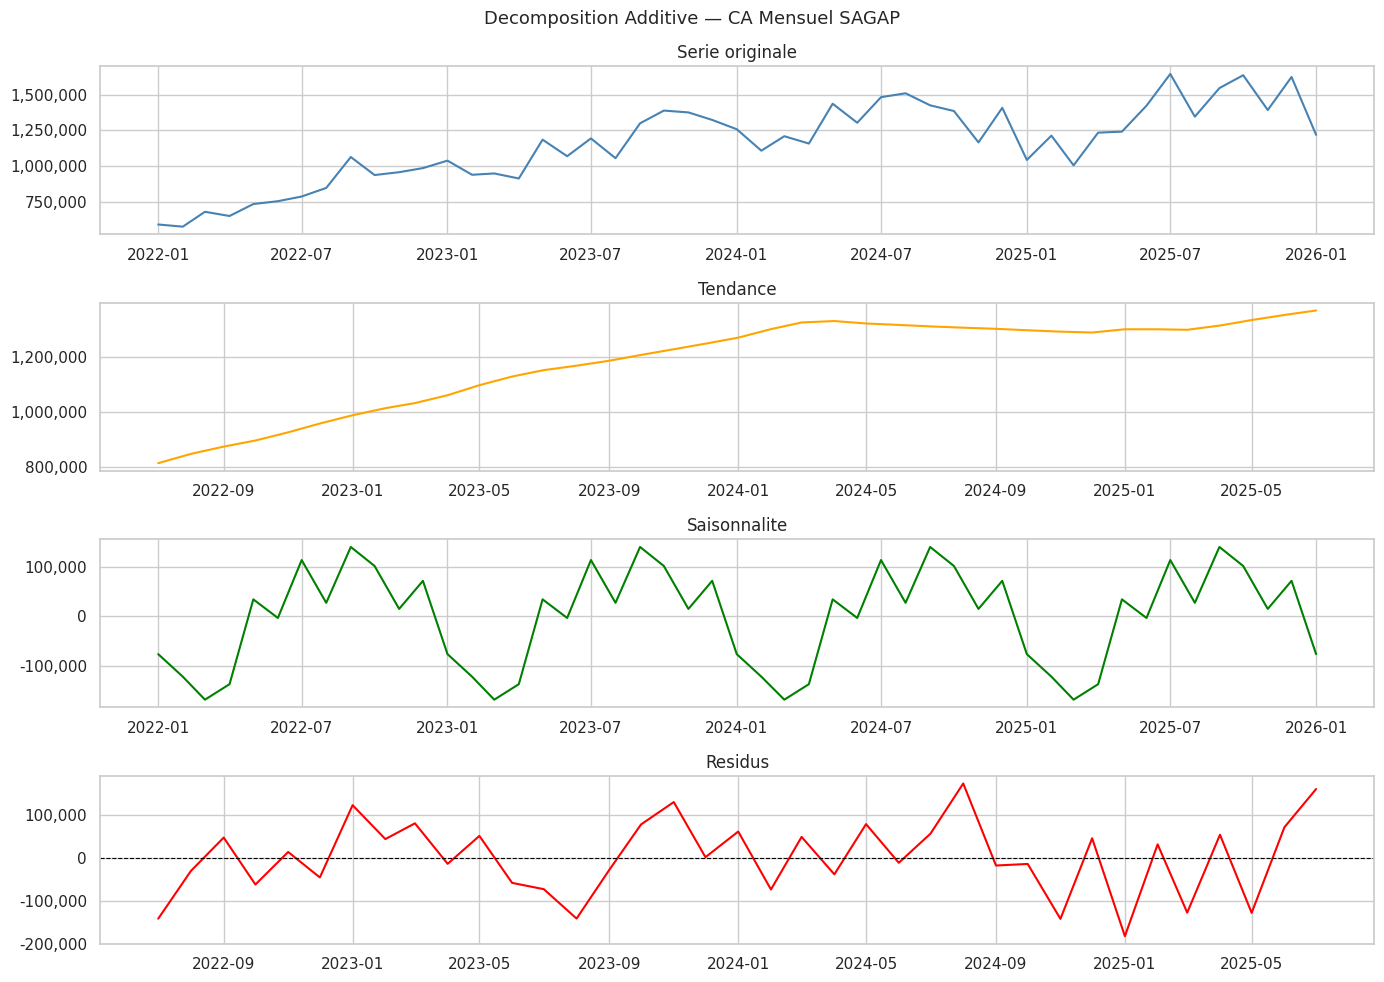

Composante saisonniere par mois :
  Jan :    -75,482 DT  III
  Fév :   -120,630 DT  IIIIII
  Mar :   -166,726 DT  IIIIIIII
  Avr :   -135,692 DT  IIIIII
  Mai : +    34,266 DT  I
  Jun :     -3,031 DT  
  Jul : +   113,019 DT  IIIII
  Aoû : +    27,356 DT  I
  Sep : +   139,253 DT  IIIIII
  Oct : +   101,138 DT  IIIII
  Nov : +    15,131 DT  
  Déc : +    71,399 DT  III

Interpretation :
  Tendance     : croissance de +553,566 DT sur la periode
  Saisonnalite : amplitude de 305,979 DT entre meilleur et pire mois
  Residus      : std = 89,259 DT — aleatoires OK
  -> Justifie HW(trend=add, seasonal=add/mul, m=12)
  -> Justifie SARIMA(d=1, m=12)
  -> Justifie Prophet(yearly_seasonality=True)


In [28]:
# ── 3.1 Décomposition additive ─────────────────────────────────
decomp = seasonal_decompose(ts, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
components = [
    (ts,              'Serie originale', 'steelblue'),
    (decomp.trend,    'Tendance',        'orange'),
    (decomp.seasonal, 'Saisonnalite',    'green'),
    (decomp.resid,    'Residus',         'red'),
]
for ax, (data, title, color) in zip(axes, components):
    ax.plot(data, color=color)
    ax.set_title(title)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:,.0f}'))
    if title == 'Residus':
        ax.axhline(0, color='black', linestyle='--', linewidth=0.8)

plt.suptitle('Decomposition Additive — CA Mensuel SAGAP', fontsize=13)
plt.tight_layout()
plt.show()

# Saisonnalite par mois
print('Composante saisonniere par mois :')
seas = decomp.seasonal[:12]
for m, v in zip(mois, seas.values):
    sign = '+' if v >= 0 else ''
    bar  = 'I' * int(abs(v) / 20000)
    print(f'  {m} : {sign}{v:>10,.0f} DT  {bar}')

# Interpretation
resid_std    = decomp.resid.dropna().std()
trend_growth = decomp.trend.dropna().iloc[-1] - decomp.trend.dropna().iloc[0]
amplitude    = seas.max() - seas.min()

qualite_resid = 'aleatoires OK' if resid_std < 100000 else 'variabilite residuelle importante'

print(f'\nInterpretation :')
print(f'  Tendance     : croissance de +{trend_growth:,.0f} DT sur la periode')
print(f'  Saisonnalite : amplitude de {amplitude:,.0f} DT entre meilleur et pire mois')
print(f'  Residus      : std = {resid_std:,.0f} DT — {qualite_resid}')
print(f'  -> Justifie HW(trend=add, seasonal=add/mul, m=12)')
print(f'  -> Justifie SARIMA(d=1, m=12)')
print(f'  -> Justifie Prophet(yearly_seasonality=True)')

In [29]:
print('CA de Septembre par année :')
sep = ts[ts.index.month == 9]
for date, val in sep.items():
    print(f'  {date.strftime("%b %Y")} : {val:>15,.0f} DT')

CA de Septembre par année :
  Sep 2022 :       1,063,183 DT
  Sep 2023 :       1,298,967 DT
  Sep 2024 :       1,424,779 DT
  Sep 2025 :       1,545,185 DT


CA Mensuel par année — Analyse saisonnalité

Mois           2022         2023         2024         2025 Tendance
Jan         591,408    1,037,923    1,257,498    1,043,000  📈 Croissant
Fév         576,097      939,044    1,107,675    1,212,738  📈 Croissant
Mar         680,214      948,326    1,208,758    1,004,936  📈 Croissant
Avr         650,790      913,162    1,157,346    1,233,784  📈 Croissant
Mai         734,336    1,184,666    1,435,948    1,240,759  📈 Croissant
Jun         754,274    1,068,898    1,302,958    1,422,307  📈 Croissant
Jul         787,032    1,193,357    1,481,827    1,644,113  📈 Croissant
Aoû         847,028    1,055,108    1,509,045    1,345,444  📈 Croissant
Sep       1,063,183    1,298,967    1,424,779    1,545,185  📈 Croissant
Oct         937,241    1,388,113    1,385,051    1,635,378  📈 Croissant
Nov         957,116    1,375,138    1,165,524    1,391,948  📈 Croissant
Déc         985,660    1,322,575    1,407,282    1,623,158  📈 Croissant


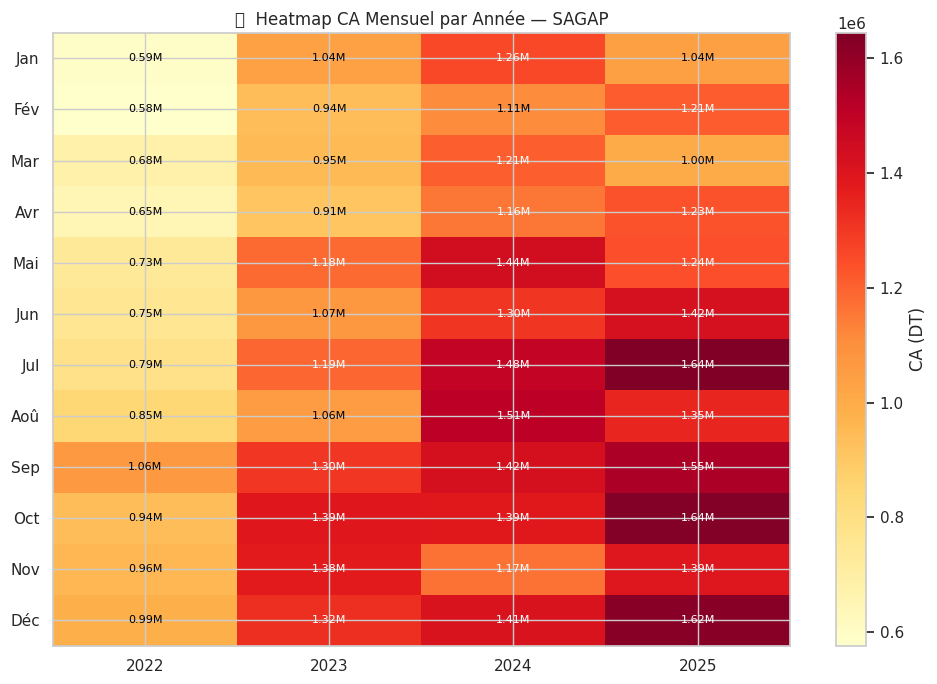

In [30]:
print('CA Mensuel par année — Analyse saisonnalité\n')
print(f'{"Mois":<6} {"2022":>12} {"2023":>12} {"2024":>12} {"2025":>12} {"Tendance"}')
print('='*75)

mois_noms = ['Jan','Fév','Mar','Avr','Mai','Jun',
             'Jul','Aoû','Sep','Oct','Nov','Déc']

for m in range(1, 13):
    vals = []
    for year in [2022, 2023, 2024, 2025]:
        v = ts[(ts.index.month == m) & (ts.index.year == year)]
        vals.append(v.values[0] if len(v) > 0 else None)

    # Tendance : croissant / stable / décroissant
    v_valid = [v for v in vals if v is not None]
    if len(v_valid) >= 2:
        if v_valid[-1] > v_valid[0] * 1.05:
            tendance = '📈 Croissant'
        elif v_valid[-1] < v_valid[0] * 0.95:
            tendance = '📉 Décroissant'
        else:
            tendance = '➡️  Stable'
    else:
        tendance = ''

    row = f'{mois_noms[m-1]:<6}'
    for v in vals:
        if v is not None:
            row += f' {v:>12,.0f}'
        else:
            row += f' {"N/A":>12}'
    row += f'  {tendance}'
    print(row)

print('='*75)

# Graphe heatmap
import matplotlib.pyplot as plt
import numpy as np

data = []
for m in range(1, 13):
    row = []
    for year in [2022, 2023, 2024, 2025]:
        v = ts[(ts.index.month == m) & (ts.index.year == year)]
        row.append(v.values[0] if len(v) > 0 else np.nan)
    data.append(row)

data = np.array(data)

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(data, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(4))
ax.set_xticklabels(['2022', '2023', '2024', '2025'])
ax.set_yticks(range(12))
ax.set_yticklabels(mois_noms)

# Valeurs dans chaque cellule
for i in range(12):
    for j in range(4):
        if not np.isnan(data[i, j]):
            ax.text(j, i, f'{data[i,j]/1e6:.2f}M',
                    ha='center', va='center', fontsize=8,
                    color='black' if data[i,j] < data.max()*0.7 else 'white')

plt.colorbar(im, ax=ax, label='CA (DT)')
ax.set_title('🗓️  Heatmap CA Mensuel par Année — SAGAP')
plt.tight_layout()
plt.show()

In [31]:
# ── 3.2 Test de Stationnarité ADF ──────────────────────────────
print('=== Test ADF (Augmented Dickey-Fuller) ===')
adf = adfuller(ts)
print(f'Statistique ADF : {adf[0]:.4f}')
print(f'p-value         : {adf[1]:.4f}')
print('Valeurs critiques :')
for k, v in adf[4].items():
    print(f'  {k} : {v:.4f}')

if adf[1] < 0.05:
    print('\n✅ Série STATIONNAIRE → d=0 pour ARIMA')
    D_ARIMA = 0
else:
    print('\n⚠️  Série NON STATIONNAIRE → d=1 pour ARIMA')
    D_ARIMA = 1

ts_diff = ts.diff().dropna()
adf2 = adfuller(ts_diff)
print(f'\nADF après diff(1) : p-value = {adf2[1]:.4f}')
print('✅ Stationnaire après diff' if adf2[1] < 0.05 else '⚠️  Toujours non stationnaire')

print(f'\n📊 Interprétation :')
print(f'  → p-value originale = {adf[1]:.4f} > 0.05 → série non stationnaire')
print(f'  → La moyenne du CA croît dans le temps → pas de niveau stable')
print(f'  → Après diff(1) : p = {adf2[1]:.4f} << 0.05 → stationnaire ✅')
print(f'  → 1 différenciation suffit → d=1 confirmé pour SARIMA')
print(f'  → Interprétation : on travaille sur les VARIATIONS mensuelles, pas le CA absolu')


=== Test ADF (Augmented Dickey-Fuller) ===
Statistique ADF : -1.8989
p-value         : 0.3326
Valeurs critiques :
  1% : -3.6104
  5% : -2.9391
  10% : -2.6081

⚠️  Série NON STATIONNAIRE → d=1 pour ARIMA

ADF après diff(1) : p-value = 0.0007
✅ Stationnaire après diff

📊 Interprétation :
  → p-value originale = 0.3326 > 0.05 → série non stationnaire
  → La moyenne du CA croît dans le temps → pas de niveau stable
  → Après diff(1) : p = 0.0007 << 0.05 → stationnaire ✅
  → 1 différenciation suffit → d=1 confirmé pour SARIMA
  → Interprétation : on travaille sur les VARIATIONS mensuelles, pas le CA absolu


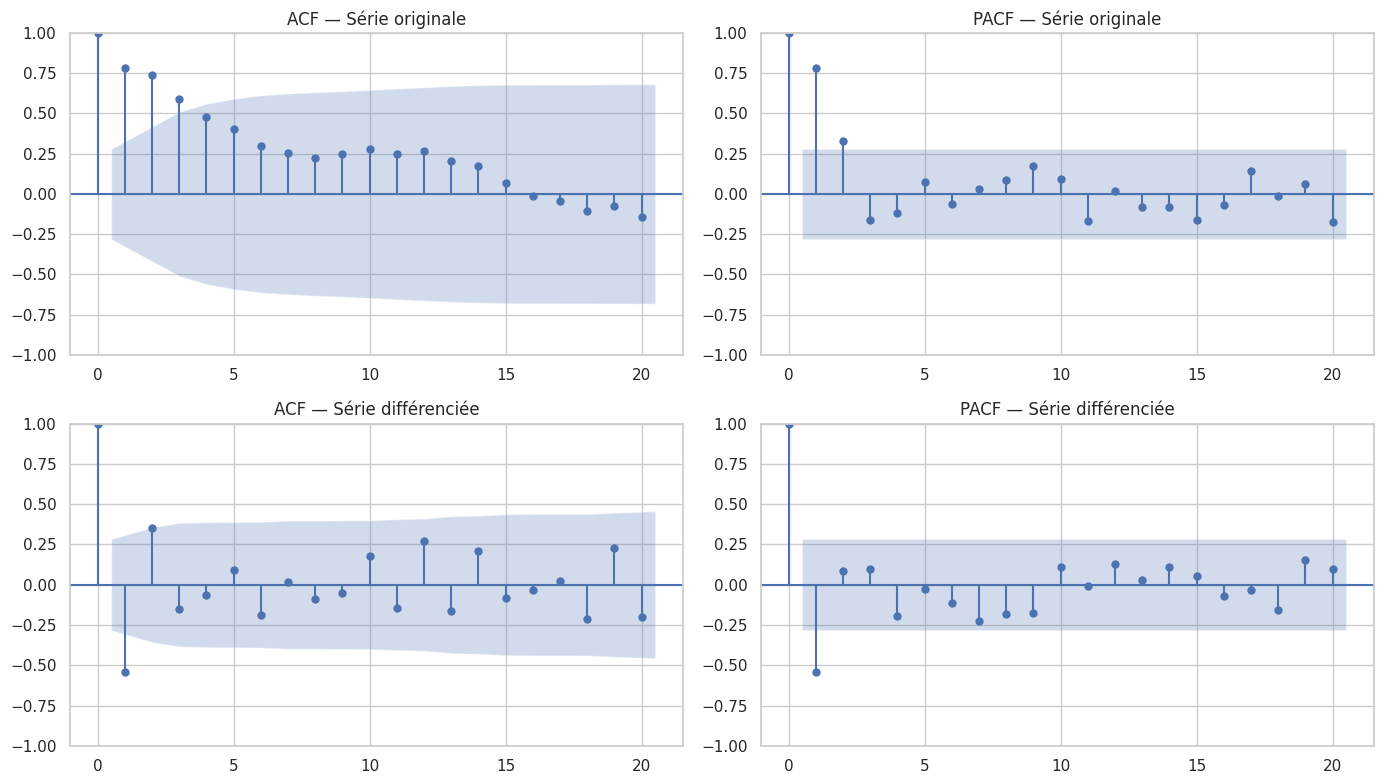

Lecture ACF/PACF :
  Pic au lag 12 → saisonnalité annuelle confirmée ✅
  PACF coupe après lag p → ordre AR
  ACF coupe après lag q → ordre MA


In [32]:
# ── 3.3 ACF / PACF ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_acf(ts,       lags=20, ax=axes[0,0], title='ACF — Série originale')
plot_pacf(ts,      lags=20, ax=axes[0,1], title='PACF — Série originale')
plot_acf(ts_diff,  lags=20, ax=axes[1,0], title='ACF — Série différenciée')
plot_pacf(ts_diff, lags=20, ax=axes[1,1], title='PACF — Série différenciée')

plt.tight_layout()
plt.show()

print('Lecture ACF/PACF :')
print('  Pic au lag 12 → saisonnalité annuelle confirmée ✅')
print('  PACF coupe après lag p → ordre AR')
print('  ACF coupe après lag q → ordre MA')

---
# ÉTAPE 4 — Model Selection and Fitting
### Split Train/Test + Entraînement HW | SARIMA | Prophet

Train : 43 mois (Jan 2022 → Jul 2025)
Test  : 6 mois (Aug 2025 → Jan 2026)


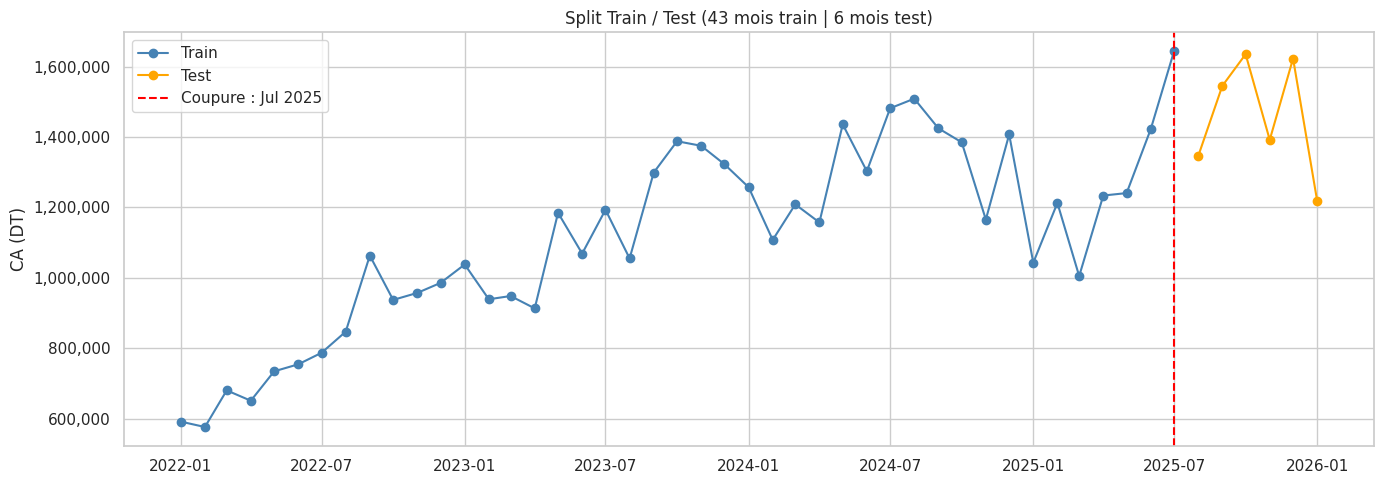


✅ Fonctions définies | all_results réinitialisé


In [33]:
# ── 4.1 Split Train / Test ─────────────────────────────────────
N_TEST   = 6
ts_train = ts.iloc[:-N_TEST]
ts_test  = ts.iloc[-N_TEST:]

print(f'Train : {len(ts_train)} mois ({ts_train.index[0].strftime("%b %Y")} → {ts_train.index[-1].strftime("%b %Y")})')
print(f'Test  : {len(ts_test)} mois ({ts_test.index[0].strftime("%b %Y")} → {ts_test.index[-1].strftime("%b %Y")})')

fig, ax = plt.subplots()
ax.plot(ts_train.index, ts_train.values, color='steelblue', marker='o', label='Train')
ax.plot(ts_test.index,  ts_test.values,  color='orange',    marker='o', label='Test')
ax.axvline(ts_train.index[-1], color='red', linestyle='--',
           label=f'Coupure : {ts_train.index[-1].strftime("%b %Y")}')
ax.set_title(f'Split Train / Test ({len(ts_train)} mois train | {len(ts_test)} mois test)')
ax.set_ylabel('CA (DT)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

# ── Fonctions évaluation + overfitting ────────────────────────
def evaluate_ts(name, y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    mape  = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    smape = np.mean(2*np.abs(y_true-y_pred)/(np.abs(y_true)+np.abs(y_pred))) * 100
    bias  = np.mean(y_pred - y_true)
    return {'name':name,'pred':y_pred,'MAE':mae,'RMSE':rmse,
            'MAPE':mape,'SMAPE':smape,'Biais':bias}

def check_overfitting(name, pred_train, pred_test):
    mape_tr = np.mean(np.abs((ts_train.values - pred_train) / ts_train.values)) * 100
    mape_te = np.mean(np.abs((ts_test.values  - pred_test)  / ts_test.values))  * 100
    ecart   = abs(mape_tr - mape_te)
    status  = '✅ Pas d\'overfitting' if ecart < 2 else '⚠️  Légère tendance' if ecart < 5 else '❌ Overfitting'
    print(f'  Overfitting : MAPE train={mape_tr:.2f}% | test={mape_te:.2f}% | écart={ecart:.2f}% → {status}')

all_results = []
print('\n✅ Fonctions définies | all_results réinitialisé')

1️⃣  Holt-Winters Additif
Principe : CA = Tendance + Saisonnalité + Erreur
Hypothèse : amplitude saisonnière constante en valeur absolue

  MAE   :      111,927 DT
  RMSE  :      142,333 DT
  MAPE  :         8.37 %
  SMAPE :         7.81 %
  Biais :       89,930 DT
  Overfitting : MAPE train=8.41% | test=8.37% | écart=0.05% → ✅ Pas d'overfitting
  ✅ Loggé dans MLflow

📊 Interprétation :
  → MAPE 8.37% → bon ✅
  → Biais +89,930 DT → surestimation systématique
  → Hypothèse additive : saisonnalité fixe en valeur absolue


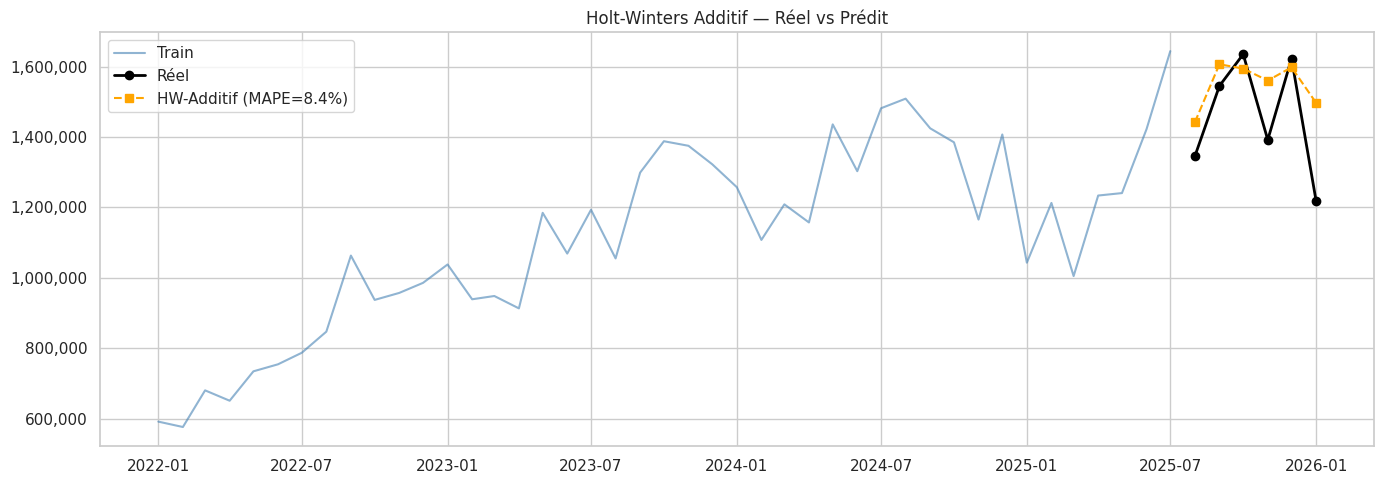

In [34]:
# ── 4.2 Modèle 1 — Holt-Winters Additif ───────────────────────
print('='*55)
print('1️⃣  Holt-Winters Additif')
print('='*55)
print('Principe : CA = Tendance + Saisonnalité + Erreur')
print('Hypothèse : amplitude saisonnière constante en valeur absolue\n')

hw_add = ExponentialSmoothing(
    ts_train, trend='add', seasonal='add', seasonal_periods=12
).fit(optimized=True)

pred_hw_add = hw_add.forecast(N_TEST).values
res_hw_add  = evaluate_ts('HW-Additif', ts_test.values, pred_hw_add)
all_results.append(res_hw_add)

print(f'  MAE   : {res_hw_add["MAE"]:>12,.0f} DT')
print(f'  RMSE  : {res_hw_add["RMSE"]:>12,.0f} DT')
print(f'  MAPE  : {res_hw_add["MAPE"]:>12.2f} %')
print(f'  SMAPE : {res_hw_add["SMAPE"]:>12.2f} %')
print(f'  Biais : {res_hw_add["Biais"]:>12,.0f} DT')
check_overfitting('HW-Additif', hw_add.fittedvalues.values, pred_hw_add)

# ── MLflow tracking ───────────────────────────────────────────
with mlflow.start_run(run_name='HW-Additif'):
    mlflow.log_param('model',            'HW-Additif')
    mlflow.log_param('trend',            'add')
    mlflow.log_param('seasonal',         'add')
    mlflow.log_param('seasonal_periods', 12)
    mlflow.log_param('n_train',          len(ts_train))
    mlflow.log_param('n_test',           len(ts_test))
    mlflow.log_metric('MAE',   res_hw_add['MAE'])
    mlflow.log_metric('RMSE',  res_hw_add['RMSE'])
    mlflow.log_metric('MAPE',  res_hw_add['MAPE'])
    mlflow.log_metric('SMAPE', res_hw_add['SMAPE'])
    mlflow.log_metric('Biais', abs(res_hw_add['Biais']))
print('  ✅ Loggé dans MLflow')

print(f'\n📊 Interprétation :')
biais = res_hw_add['Biais']
print(f'  → MAPE {res_hw_add["MAPE"]:.2f}% → {"bon ✅" if res_hw_add["MAPE"] < 10 else "acceptable ⚠️"}')
print(f'  → Biais {biais:+,.0f} DT → {"surestimation" if biais > 0 else "sous-estimation"} systématique')
print(f'  → Hypothèse additive : saisonnalité fixe en valeur absolue')

fig, ax = plt.subplots()
ax.plot(ts_train.index, ts_train.values, color='steelblue', alpha=0.6, label='Train')
ax.plot(ts_test.index, ts_test.values, color='black', marker='o', linewidth=2, label='Réel')
ax.plot(ts_test.index, pred_hw_add, color='orange', marker='s', linestyle='--',
        label=f'HW-Additif (MAPE={res_hw_add["MAPE"]:.1f}%)')
ax.set_title('Holt-Winters Additif — Réel vs Prédit')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()


2️⃣  Holt-Winters Multiplicatif
Principe : CA = Tendance × Saisonnalité × Erreur
Hypothèse : amplitude saisonnière proportionnelle au niveau du CA

  MAE   :      105,503 DT
  RMSE  :      131,515 DT
  MAPE  :         7.88 %
  SMAPE :         7.41 %
  Biais :       98,805 DT
  Overfitting : MAPE train=7.01% | test=7.88% | écart=0.87% → ✅ Pas d'overfitting
  ✅ Loggé dans MLflow

📊 Interprétation :
  → MAPE 7.88% → bon ✅
  → Biais +98,805 DT → surestimation
  → Hypothèse multiplicative : saisonnalité GRANDIT avec le CA
  → Justifiée car amplitude saisonnière augmente de 2022 à 2025 ✅


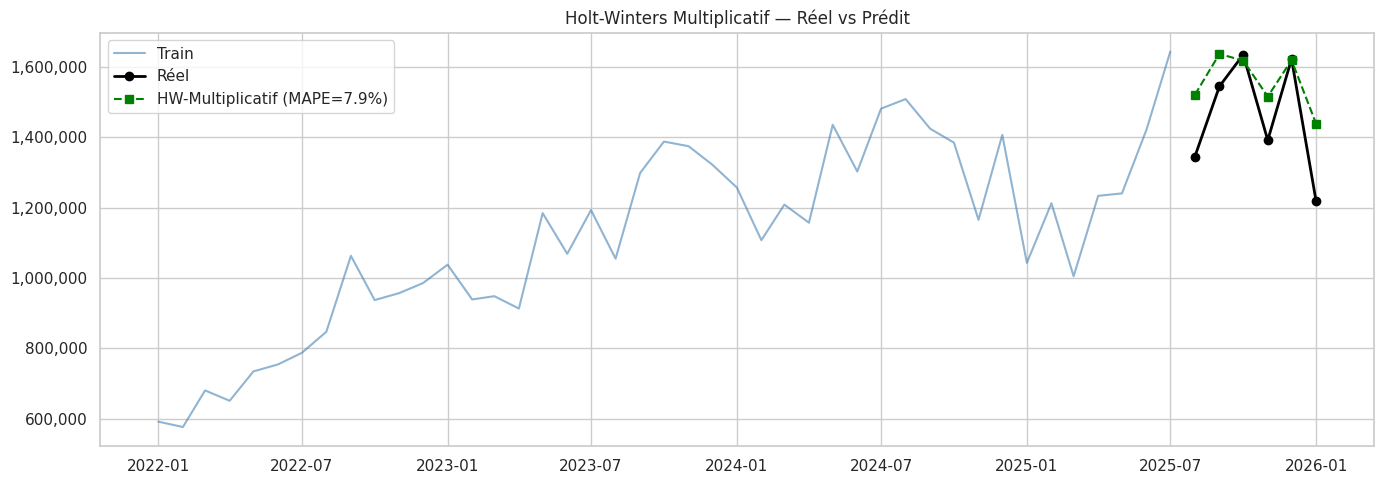

In [35]:
# ── 4.3 Modèle 2 — Holt-Winters Multiplicatif ─────────────────
print('='*55)
print('2️⃣  Holt-Winters Multiplicatif')
print('='*55)
print('Principe : CA = Tendance × Saisonnalité × Erreur')
print('Hypothèse : amplitude saisonnière proportionnelle au niveau du CA\n')

hw_mul = ExponentialSmoothing(
    ts_train, trend='add', seasonal='mul', seasonal_periods=12
).fit(optimized=True)

pred_hw_mul = hw_mul.forecast(N_TEST).values
res_hw_mul  = evaluate_ts('HW-Multiplicatif', ts_test.values, pred_hw_mul)
all_results.append(res_hw_mul)

print(f'  MAE   : {res_hw_mul["MAE"]:>12,.0f} DT')
print(f'  RMSE  : {res_hw_mul["RMSE"]:>12,.0f} DT')
print(f'  MAPE  : {res_hw_mul["MAPE"]:>12.2f} %')
print(f'  SMAPE : {res_hw_mul["SMAPE"]:>12.2f} %')
print(f'  Biais : {res_hw_mul["Biais"]:>12,.0f} DT')
check_overfitting('HW-Multiplicatif', hw_mul.fittedvalues.values, pred_hw_mul)

# ── MLflow tracking ───────────────────────────────────────────
with mlflow.start_run(run_name='HW-Multiplicatif'):
    mlflow.log_param('model',            'HW-Multiplicatif')
    mlflow.log_param('trend',            'add')
    mlflow.log_param('seasonal',         'mul')
    mlflow.log_param('seasonal_periods', 12)
    mlflow.log_param('n_train',          len(ts_train))
    mlflow.log_param('n_test',           len(ts_test))
    mlflow.log_metric('MAE',   res_hw_mul['MAE'])
    mlflow.log_metric('RMSE',  res_hw_mul['RMSE'])
    mlflow.log_metric('MAPE',  res_hw_mul['MAPE'])
    mlflow.log_metric('SMAPE', res_hw_mul['SMAPE'])
    mlflow.log_metric('Biais', abs(res_hw_mul['Biais']))
print('  ✅ Loggé dans MLflow')

print(f'\n📊 Interprétation :')
biais = res_hw_mul['Biais']
print(f'  → MAPE {res_hw_mul["MAPE"]:.2f}% → {"bon ✅" if res_hw_mul["MAPE"] < 10 else "acceptable ⚠️"}')
print(f'  → Biais {biais:+,.0f} DT → {"surestimation" if biais > 0 else "sous-estimation"}')
print(f'  → Hypothèse multiplicative : saisonnalité GRANDIT avec le CA')
print(f'  → Justifiée car amplitude saisonnière augmente de 2022 à 2025 ✅')

fig, ax = plt.subplots()
ax.plot(ts_train.index, ts_train.values, color='steelblue', alpha=0.6, label='Train')
ax.plot(ts_test.index, ts_test.values, color='black', marker='o', linewidth=2, label='Réel')
ax.plot(ts_test.index, pred_hw_mul, color='green', marker='s', linestyle='--',
        label=f'HW-Multiplicatif (MAPE={res_hw_mul["MAPE"]:.1f}%)')
ax.set_title('Holt-Winters Multiplicatif — Réel vs Prédit')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()


3️⃣  SARIMA — Grid Search
Principe : modèle statistique combinant AR, différenciation et MA
d=1 forcé (confirmé par ADF), saisonnalité fixée (1,1,1,12)

Toutes les combinaisons (AIC) :
    order      seasonal    AIC    BIC
(1, 1, 1) (1, 1, 1, 12) 436.04 439.91
(0, 1, 1) (1, 1, 1, 12) 440.39 443.48
(1, 1, 0) (1, 1, 1, 12) 460.81 464.14
(0, 1, 0) (1, 1, 1, 12) 472.40 474.90

✅ Meilleur : SARIMA(1, 1, 1)(1,1,1,12) | AIC=436.04
  MAE   :      186,871 DT
  RMSE  :      201,511 DT
  MAPE  :        13.49 %
  SMAPE :        12.45 %
  Biais :      186,871 DT
  Overfitting : MAPE train=11.70% | test=13.49% | écart=1.78% → ✅ Pas d'overfitting
  ✅ Loggé dans MLflow

📊 Interprétation :
  → Paramètres sélectionnés : p=1 (AR), d=1 (diff), q=1 (MA)
  → d=1 confirme la non-stationnarité détectée par ADF ✅
  → AIC=436.04 → critère de sélection minimisé ✅
  → MAPE 13.49% → acceptable ⚠️
  → Biais +186,871 DT → surestimation


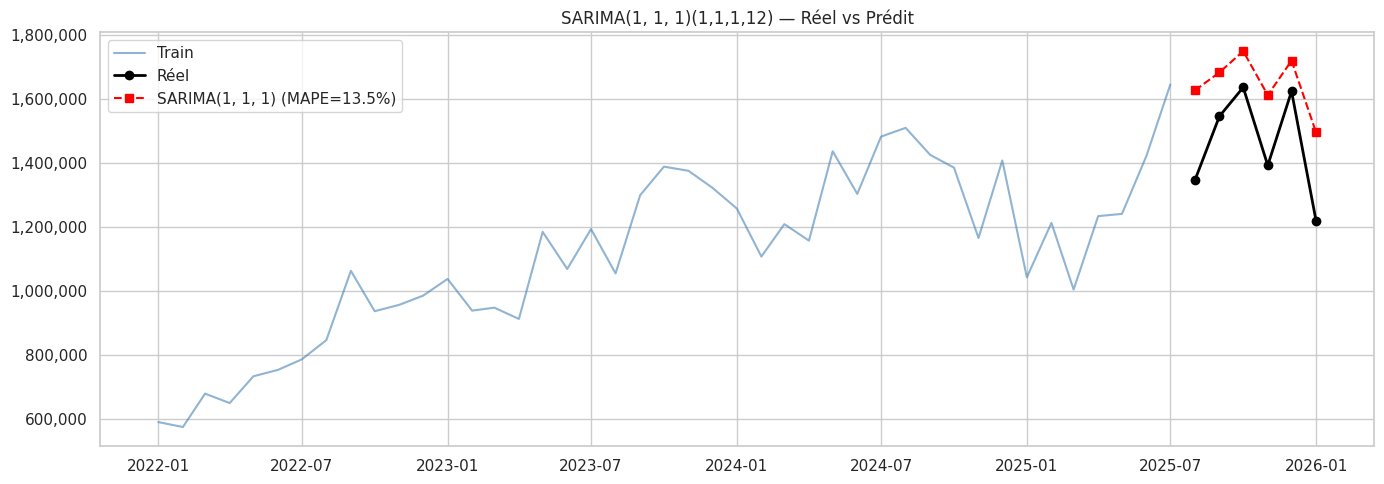

In [36]:
# ── 4.4 Modèle 3 — SARIMA Grid Search ─────────────────────────
print('='*55)
print('3️⃣  SARIMA — Grid Search')
print('='*55)
print('Principe : modèle statistique combinant AR, différenciation et MA')
print('d=1 forcé (confirmé par ADF), saisonnalité fixée (1,1,1,12)\n')

best_aic    = np.inf
best_order  = None
best_sarima = None
results_grid = []

for p, d, q in itertools.product([0, 1], [1], [0, 1]):
    try:
        m = SARIMAX(
            ts_train,
            order=(p, d, q),
            seasonal_order=(1, 1, 1, 12),
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)
        results_grid.append({
            'order': (p, d, q), 'seasonal': (1, 1, 1, 12),
            'AIC': m.aic, 'BIC': m.bic, 'model': m
        })
        if m.aic < best_aic:
            best_aic    = m.aic
            best_order  = (p, d, q)
            best_sarima = m
    except:
        continue

best_seas = (1, 1, 1, 12)

df_grid = pd.DataFrame([{k: v for k, v in r.items() if k != 'model'}
                         for r in results_grid]).sort_values('AIC')
print('Toutes les combinaisons (AIC) :')
print(df_grid[['order', 'seasonal', 'AIC', 'BIC']].to_string(index=False))
print(f'\n✅ Meilleur : SARIMA{best_order}(1,1,1,12) | AIC={best_aic:.2f}')

pred_sarima = best_sarima.forecast(steps=N_TEST).values
sarima_name = f'SARIMA{best_order}'
res_sarima  = evaluate_ts(sarima_name, ts_test.values, pred_sarima)
all_results.append(res_sarima)

print(f'  MAE   : {res_sarima["MAE"]:>12,.0f} DT')
print(f'  RMSE  : {res_sarima["RMSE"]:>12,.0f} DT')
print(f'  MAPE  : {res_sarima["MAPE"]:>12.2f} %')
print(f'  SMAPE : {res_sarima["SMAPE"]:>12.2f} %')
print(f'  Biais : {res_sarima["Biais"]:>12,.0f} DT')
check_overfitting(sarima_name, best_sarima.fittedvalues.values, pred_sarima)

# ── MLflow tracking ───────────────────────────────────────────
with mlflow.start_run(run_name=sarima_name):
    mlflow.log_param('model',   'SARIMA')
    mlflow.log_param('p',       best_order[0])
    mlflow.log_param('d',       best_order[1])
    mlflow.log_param('q',       best_order[2])
    mlflow.log_param('P',       1)
    mlflow.log_param('D',       1)
    mlflow.log_param('Q',       1)
    mlflow.log_param('m',       12)
    mlflow.log_param('AIC',     best_aic)
    mlflow.log_param('n_train', len(ts_train))
    mlflow.log_param('n_test',  len(ts_test))
    mlflow.log_metric('MAE',   res_sarima['MAE'])
    mlflow.log_metric('RMSE',  res_sarima['RMSE'])
    mlflow.log_metric('MAPE',  res_sarima['MAPE'])
    mlflow.log_metric('SMAPE', res_sarima['SMAPE'])
    mlflow.log_metric('Biais', abs(res_sarima['Biais']))
print('  ✅ Loggé dans MLflow')

print(f'\n📊 Interprétation :')
p, d, q = best_order
print(f'  → Paramètres sélectionnés : p={p} (AR), d={d} (diff), q={q} (MA)')
print(f'  → d=1 confirme la non-stationnarité détectée par ADF ✅')
print(f'  → AIC={best_aic:.2f} → critère de sélection minimisé ✅')
print(f'  → MAPE {res_sarima["MAPE"]:.2f}% → {"bon ✅" if res_sarima["MAPE"] < 10 else "acceptable ⚠️"}')
biais = res_sarima['Biais']
print(f'  → Biais {biais:+,.0f} DT → {"surestimation" if biais > 0 else "sous-estimation"}')

fig, ax = plt.subplots()
ax.plot(ts_train.index, ts_train.values, color='steelblue', alpha=0.6, label='Train')
ax.plot(ts_test.index, ts_test.values, color='black', marker='o', linewidth=2, label='Réel')
ax.plot(ts_test.index, pred_sarima, color='red', marker='s', linestyle='--',
        label=f'{sarima_name} (MAPE={res_sarima["MAPE"]:.1f}%)')
ax.set_title(f'{sarima_name}(1,1,1,12) — Réel vs Prédit')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()


10:36:10 - cmdstanpy - INFO - Chain [1] start processing


4️⃣  Prophet (Meta/Facebook)
Principe : décomposition flexible tendance + saisonnalité + jours fériés
Avantage : gère les ruptures de tendance et les valeurs atypiques



10:36:10 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet entraîné
  MAE   :       92,136 DT
  RMSE  :      103,450 DT
  MAPE  :         6.20 %
  SMAPE :         6.29 %
  Biais :      -35,922 DT
  Overfitting : MAPE train=5.78% | test=6.20% | écart=0.42% → ✅ Pas d'overfitting
  ✅ Loggé dans MLflow

📊 Interprétation :
  → MAPE 6.20% → bon ✅
  → Biais -35,922 DT → sous-estimation
  → IC 95% fourni automatiquement ✅
  → Avantage : capture bien les transitions (ex: creux Janvier)


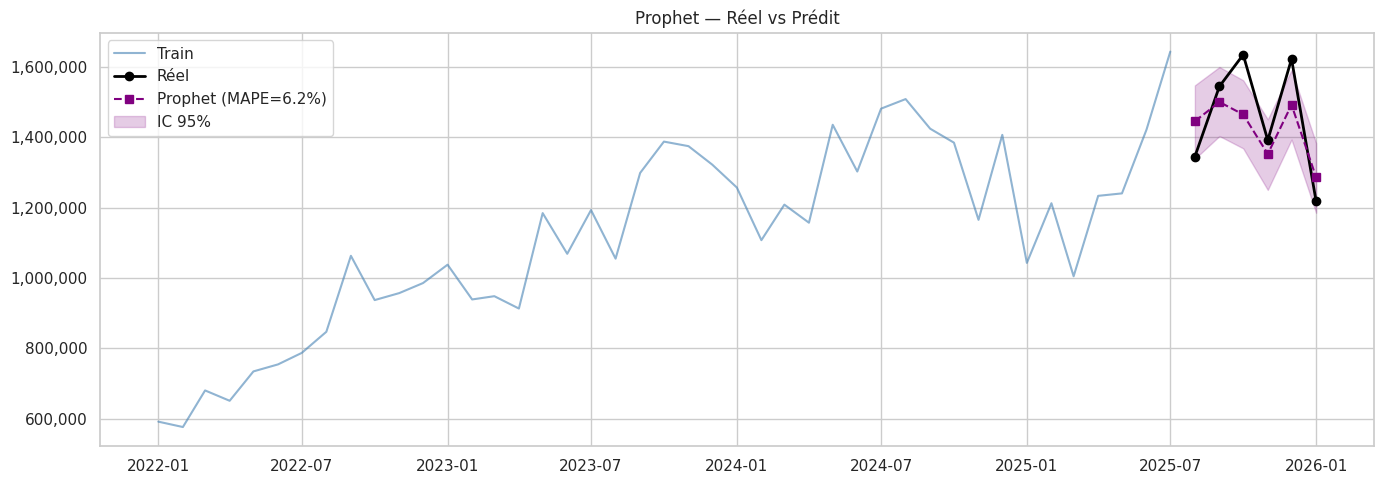

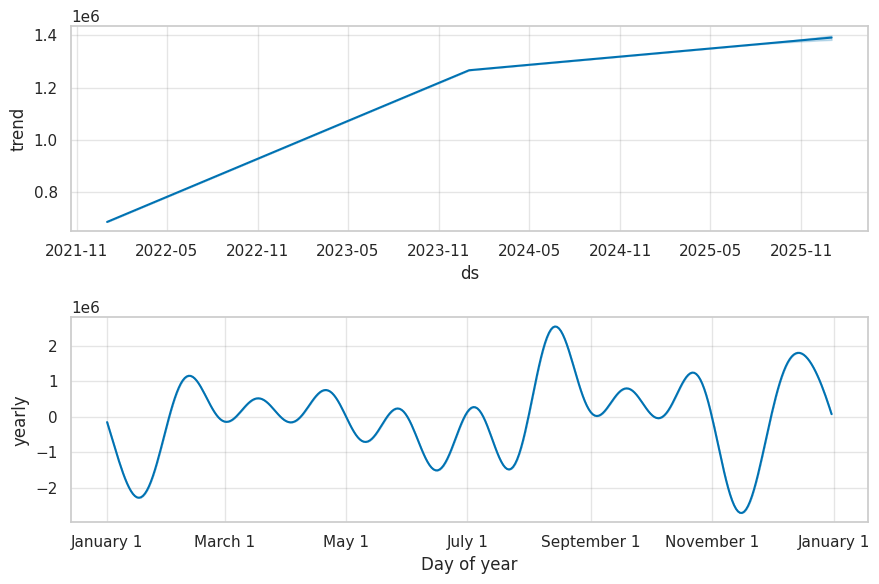

In [37]:
# ── 4.5 Modèle 4 — Prophet ─────────────────────────────────────
print('='*55)
print('4️⃣  Prophet (Meta/Facebook)')
print('='*55)
print('Principe : décomposition flexible tendance + saisonnalité + jours fériés')
print('Avantage : gère les ruptures de tendance et les valeurs atypiques\n')

df_train_prophet = pd.DataFrame({
    'ds': ts_train.index, 'y': ts_train.values
})

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='additive'
)
prophet_model.fit(df_train_prophet)
print('✅ Prophet entraîné')

future_test    = prophet_model.make_future_dataframe(periods=N_TEST, freq='MS')
fc_test        = prophet_model.predict(future_test)
pred_prophet   = fc_test['yhat'].iloc[-N_TEST:].values
ci_low_pr      = fc_test['yhat_lower'].iloc[-N_TEST:].values
ci_high_pr     = fc_test['yhat_upper'].iloc[-N_TEST:].values

res_prophet = evaluate_ts('Prophet', ts_test.values, pred_prophet)
all_results.append(res_prophet)

print(f'  MAE   : {res_prophet["MAE"]:>12,.0f} DT')
print(f'  RMSE  : {res_prophet["RMSE"]:>12,.0f} DT')
print(f'  MAPE  : {res_prophet["MAPE"]:>12.2f} %')
print(f'  SMAPE : {res_prophet["SMAPE"]:>12.2f} %')
print(f'  Biais : {res_prophet["Biais"]:>12,.0f} DT')

pred_train_pr = prophet_model.predict(df_train_prophet)['yhat'].values
check_overfitting('Prophet', pred_train_pr, pred_prophet)

# ── MLflow tracking ───────────────────────────────────────────
with mlflow.start_run(run_name='Prophet'):
    mlflow.log_param('model',              'Prophet')
    mlflow.log_param('yearly_seasonality', True)
    mlflow.log_param('seasonality_mode',   'additive')
    mlflow.log_param('n_train',            len(ts_train))
    mlflow.log_param('n_test',             len(ts_test))
    mlflow.log_metric('MAE',   res_prophet['MAE'])
    mlflow.log_metric('RMSE',  res_prophet['RMSE'])
    mlflow.log_metric('MAPE',  res_prophet['MAPE'])
    mlflow.log_metric('SMAPE', res_prophet['SMAPE'])
    mlflow.log_metric('Biais', abs(res_prophet['Biais']))
print('  ✅ Loggé dans MLflow')

print(f'\n📊 Interprétation :')
biais = res_prophet['Biais']
print(f'  → MAPE {res_prophet["MAPE"]:.2f}% → {"bon ✅" if res_prophet["MAPE"] < 10 else "acceptable ⚠️"}')
print(f'  → Biais {biais:+,.0f} DT → {"surestimation" if biais > 0 else "sous-estimation"}')
print(f'  → IC 95% fourni automatiquement ✅')
print(f'  → Avantage : capture bien les transitions (ex: creux Janvier)')

fig, ax = plt.subplots()
ax.plot(ts_train.index, ts_train.values, color='steelblue', alpha=0.6, label='Train')
ax.plot(ts_test.index, ts_test.values, color='black', marker='o', linewidth=2, label='Réel')
ax.plot(ts_test.index, pred_prophet, color='purple', marker='s', linestyle='--',
        label=f'Prophet (MAPE={res_prophet["MAPE"]:.1f}%)')
ax.fill_between(ts_test.index, ci_low_pr, ci_high_pr,
                alpha=0.2, color='purple', label='IC 95%')
ax.set_title('Prophet — Réel vs Prédit')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

prophet_model.plot_components(fc_test)
plt.show()


---
# ÉTAPE 5 — Model Prediction and Forecasting
### Sélection du meilleur modèle + Prévision Fév 2026 → Jan 2027

Modele                              MAE       RMSE     MAPE    SMAPE        Biais
Prophet                          92,136    103,450    6.20%    6.29%      -35,922
HW-Multiplicatif                105,503    131,515    7.88%    7.41%       98,805
HW-Additif                      111,927    142,333    8.37%    7.81%       89,930
SARIMA(1, 1, 1)                 186,871    201,511   13.49%   12.45%      186,871

🏆 Meilleur modèle : Prophet (MAPE=6.20%)


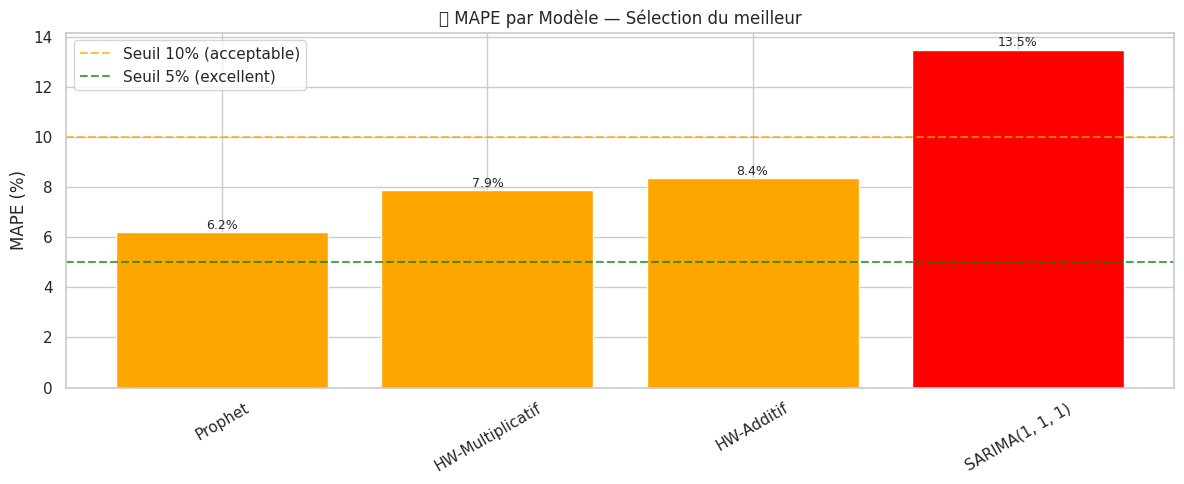


📊 Interprétation :
  → Référence industrie prévision des ventes : MAPE 10-15%
  → Meilleur modèle : Prophet avec MAPE=6.20% → au-dessus du standard ✅
  → Prophet                   MAPE=6.20% → bon ✅
  → HW-Multiplicatif          MAPE=7.88% → bon ✅
  → HW-Additif                MAPE=8.37% → bon ✅
  → SARIMA(1, 1, 1)           MAPE=13.49% → acceptable ⚠️


In [38]:
# ── 5.1 Sélection meilleur modèle ─────────────────────────────
df_results = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'pred'}
    for r in all_results
]).set_index('name').sort_values('MAPE')

print('=' * 75)
print(f'{"Modele":<28} {"MAE":>10} {"RMSE":>10} {"MAPE":>8} {"SMAPE":>8} {"Biais":>12}')
print('=' * 75)
for _, row in df_results.iterrows():
    mae=float(row['MAE']); rmse=float(row['RMSE'])
    mape=float(row['MAPE']); smape=float(row['SMAPE'])
    biais=float(row['Biais'])
    print(f'{row.name:<28} {mae:>10,.0f} {rmse:>10,.0f} {mape:>7.2f}% {smape:>7.2f}% {biais:>12,.0f}')
print('=' * 75)

best_ts_name = df_results['MAPE'].idxmin()
best_mape    = float(df_results.loc[best_ts_name, 'MAPE'])
print(f'\n🏆 Meilleur modèle : {best_ts_name} (MAPE={best_mape:.2f}%)')

# Graphe MAPE coloré
fig, ax = plt.subplots(figsize=(12, 5))
vals   = df_results['MAPE'].astype(float)
colors = ['green' if v < 5 else 'orange' if v < 10 else 'red' for v in vals.values]
bars   = ax.bar(vals.index, vals.values, color=colors)
ax.axhline(10, color='orange', linestyle='--', label='Seuil 10% (acceptable)', alpha=0.7)
ax.axhline(5,  color='green',  linestyle='--', label='Seuil 5% (excellent)',   alpha=0.7)
ax.set_title('📊 MAPE par Modèle — Sélection du meilleur')
ax.set_ylabel('MAPE (%)')
ax.tick_params(axis='x', rotation=30)
for bar, val in zip(bars, vals.values):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+vals.max()*0.01,
            f'{val:.1f}%', ha='center', fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()

print(f'\n📊 Interprétation :')
print(f'  → Référence industrie prévision des ventes : MAPE 10-15%')
print(f'  → Meilleur modèle : {best_ts_name} avec MAPE={best_mape:.2f}% → au-dessus du standard ✅')
for _, row in df_results.iterrows():
    mape = float(row['MAPE'])
    qualite = 'excellent ✅' if mape < 5 else 'bon ✅' if mape < 10 else 'acceptable ⚠️'
    print(f'  → {row.name:<25} MAPE={mape:.2f}% → {qualite}')


In [39]:
# ── 5.2 Prévision 12 mois — Réentraîner sur toute la série ────
print(f'Réentraînement de {best_ts_name} sur {len(ts)} mois...')
N_PRED = 12

if 'HW-Additif' in best_ts_name:
    fm = ExponentialSmoothing(ts, trend='add', seasonal='add', seasonal_periods=12).fit()
    forecast_vals = fm.forecast(N_PRED).values

elif 'HW-Multiplicatif' in best_ts_name:
    fm = ExponentialSmoothing(ts, trend='add', seasonal='mul', seasonal_periods=12).fit()
    forecast_vals = fm.forecast(N_PRED).values

elif 'SARIMA' in best_ts_name:
    fm = SARIMAX(ts, order=best_order, seasonal_order=best_seas,
                 enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    forecast_vals = fm.forecast(steps=N_PRED).values

elif 'Prophet' in best_ts_name:
    df_full = pd.DataFrame({'ds': ts.index, 'y': ts.values})
    fm = Prophet(yearly_seasonality=True, weekly_seasonality=False,
                 daily_seasonality=False, seasonality_mode='additive')
    fm.fit(df_full)
    future_full   = fm.make_future_dataframe(periods=N_PRED, freq='MS')
    fc_full       = fm.predict(future_full)
    forecast_vals = fc_full['yhat'].iloc[-N_PRED:].values

future_dates = pd.date_range(
    ts.index[-1] + pd.DateOffset(months=1), periods=N_PRED, freq='MS'
)

df_pred = pd.DataFrame({
    'date': future_dates, 'year': future_dates.year,
    'month': future_dates.month,
    'predicted_sales': forecast_vals, 'is_prediction': 1
})

ca_2024      = ts[ts.index.year == 2024].sum()
ca_2025      = ts[ts.index.year == 2025].sum()
ca_prev      = df_pred['predicted_sales'].sum()
croissance   = (ca_prev - ca_2025) / ca_2025 * 100

print(f'\nPredictions {best_ts_name} :')
for _, row in df_pred.iterrows():
    print(f'  {row["date"].strftime("%b %Y")} -> {row["predicted_sales"]:>15,.2f} DT')

print(f'\n{"="*55}')
print(f'CA reel 2024       : {ca_2024:>15,.2f} DT')
print(f'CA reel 2025       : {ca_2025:>15,.2f} DT')
print(f'CA prevu           : {ca_prev:>15,.2f} DT')
print(f'Croissance 25->26  : {croissance:>15.2f} %')
print(f'Modele             : {best_ts_name}')
print(f'MAPE test          : {best_mape:.2f}%')
print('='*55)


print(f'  -> CA prevu : {ca_prev:,.0f} DT')
print(f'  -> Croissance prevue : {croissance:.2f}%')


10:36:11 - cmdstanpy - INFO - Chain [1] start processing
10:36:11 - cmdstanpy - INFO - Chain [1] done processing


Réentraînement de Prophet sur 49 mois...

Predictions Prophet :
  Feb 2026 ->    1,334,374.60 DT
  Mar 2026 ->    1,303,395.04 DT
  Apr 2026 ->    1,326,820.25 DT
  May 2026 ->    1,491,650.07 DT
  Jun 2026 ->    1,470,686.08 DT
  Jul 2026 ->    1,581,405.09 DT
  Aug 2026 ->    1,468,124.93 DT
  Sep 2026 ->    1,640,153.09 DT
  Oct 2026 ->    1,628,716.07 DT
  Nov 2026 ->    1,536,722.35 DT
  Dec 2026 ->    1,576,778.62 DT
  Jan 2027 ->    1,441,487.04 DT

CA reel 2024       :   15,843,689.48 DT
CA reel 2025       :   16,342,751.14 DT
CA prevu           :   17,800,313.23 DT
Croissance 25->26  :            8.92 %
Modele             : Prophet
MAPE test          : 6.20%
  -> CA prevu : 17,800,313 DT
  -> Croissance prevue : 8.92%


---
# ÉTAPE 6 — Model Evaluation
### Visualisation finale + Comparaison + ClickHouse

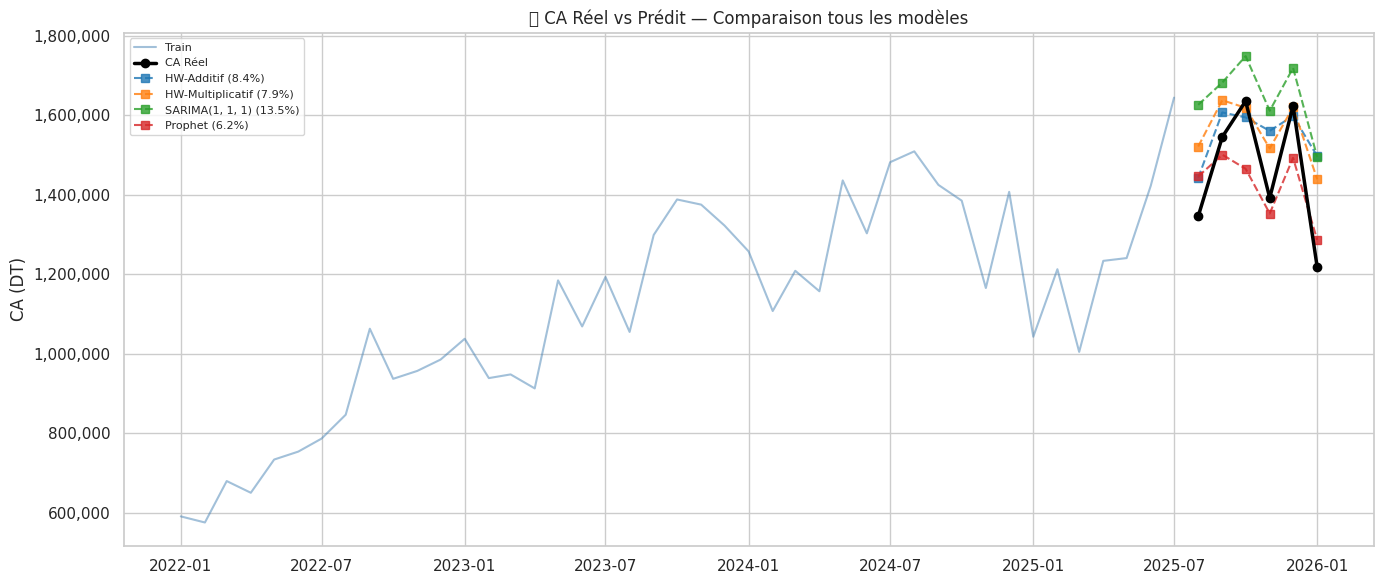

In [40]:
# ── 6.1 Graphe comparatif — tous les modèles ──────────────────
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(ts_train.index, ts_train.values,
        color='steelblue', linewidth=1.5, alpha=0.5, label='Train')
ax.plot(ts_test.index, ts_test.values,
        color='black', marker='o', linewidth=2.5, label='CA Réel', zorder=5)

palette = plt.cm.tab10.colors
for i, r in enumerate(all_results):
    ax.plot(ts_test.index, r['pred'],
            label=f"{r['name']} ({float(r['MAPE']):.1f}%)",
            marker='s', linestyle='--',
            color=palette[i % len(palette)], alpha=0.8)

ax.set_title('📈 CA Réel vs Prédit — Comparaison tous les modèles')
ax.set_ylabel('CA (DT)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

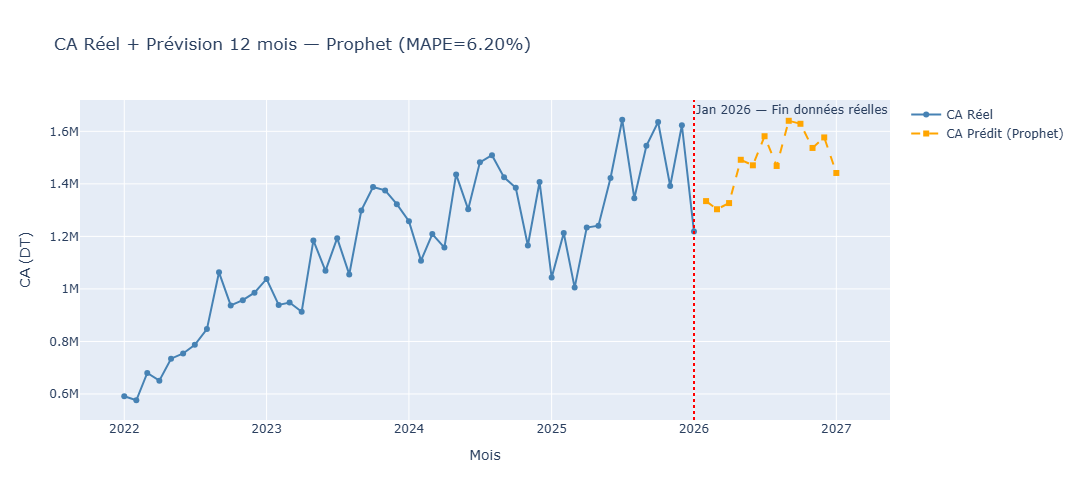

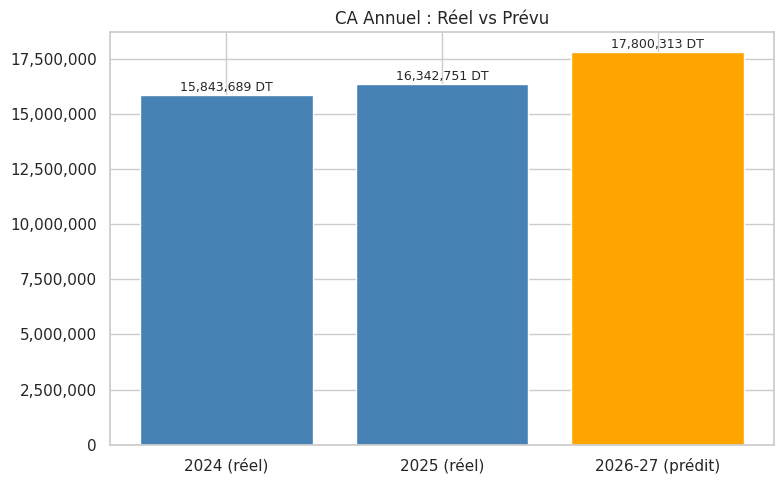

In [41]:
# ── 6.2 Graphe Plotly — Historique + Prévision ────────────────
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=ts.index, y=ts.values, name='CA Réel',
    mode='lines+markers', line=dict(color='steelblue', width=2)
))
fig.add_trace(go.Scatter(
    x=df_pred['date'], y=df_pred['predicted_sales'],
    name=f'CA Prédit ({best_ts_name})',
    mode='lines+markers',
    line=dict(color='orange', width=2, dash='dash'),
    marker=dict(size=6, symbol='square')
))
fig.add_vline(
    x=ts.index[-1].timestamp()*1000,
    line_dash='dot', line_color='red',
    annotation_text=f'{ts.index[-1].strftime("%b %Y")} — Fin données réelles'
)
fig.update_layout(
    title=f'CA Réel + Prévision 12 mois — {best_ts_name} (MAPE={best_mape:.2f}%)',
    xaxis_title='Mois', yaxis_title='CA (DT)',
    hovermode='x unified', height=500
)
fig.show()

# Graphe annuel
fig2, ax = plt.subplots(figsize=(8, 5))
ax.bar(['2024 (réel)', '2025 (réel)', '2026-27 (prédit)'],
       [ca_2024, ca_2025, ca_prev],
       color=['steelblue', 'steelblue', 'orange'])
for i, v in enumerate([ca_2024, ca_2025, ca_prev]):
    ax.text(i, v + max(ca_2024,ca_2025,ca_prev)*0.01,
            f'{v:,.0f} DT', ha='center', fontsize=9)
ax.set_title('CA Annuel : Réel vs Prévu')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

In [42]:
# ── 6.3 Écriture dans ClickHouse Gold ─────────────────────────
client2 = clickhouse_connect.get_client(
    host='clickhouse', port=8123,
    user='default', password='clickhouse123', database='gold'
)

# Drop et recréer la table proprement
client2.command('DROP TABLE IF EXISTS gold.ml_predictions')
client2.command("""
    CREATE TABLE gold.ml_predictions (
        date             Date,
        year             Int32,
        month            Int32,
        predicted_sales  Float64,
        is_prediction    Int8
    ) ENGINE = MergeTree()
    ORDER BY date
""")

# Convertir date
df_insert = df_pred[['date', 'year', 'month', 'predicted_sales', 'is_prediction']].copy()
df_insert['date'] = pd.to_datetime(df_insert['date']).dt.date

client2.insert_df('gold.ml_predictions', df_insert)

check = client2.query_df('SELECT * FROM gold.ml_predictions ORDER BY date')
print(f'✅ {len(check)} prédictions écrites dans ClickHouse Gold')
print(check.to_string(index=False))

✅ 12 prédictions écrites dans ClickHouse Gold
      date  year  month  predicted_sales  is_prediction
2026-02-01  2026      2     1,334,374.60              1
2026-03-01  2026      3     1,303,395.04              1
2026-04-01  2026      4     1,326,820.25              1
2026-05-01  2026      5     1,491,650.07              1
2026-06-01  2026      6     1,470,686.08              1
2026-07-01  2026      7     1,581,405.09              1
2026-08-01  2026      8     1,468,124.93              1
2026-09-01  2026      9     1,640,153.09              1
2026-10-01  2026     10     1,628,716.07              1
2026-11-01  2026     11     1,536,722.35              1
2026-12-01  2026     12     1,576,778.62              1
2027-01-01  2027      1     1,441,487.04              1
